<a href="https://colab.research.google.com/github/saulotorres7031-stack/Tareas1/blob/main/L05_Red_Neuronal_Densa_TF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red Neuronal Densa en TensorFlow
## Dr. Carlos Villaseñor

Paso 1. Correr paqueterias

In [102]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Paso 2. Carga el archivo 'auto-mpg.csv' y haz la lectura con pandas

In [104]:
!wget 'https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/BreastCancerWisconsin.csv'

--2026-03-09 16:20:20--  https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/BreastCancerWisconsin.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/BreastCancerWisconsin.csv [following]
--2026-03-09 16:20:20--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/BreastCancerWisconsin.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 125204 (122K) [text/plain]
Saving to: ‘BreastCancerWisconsin.csv.6’

BreastCancerWiscons 100%[===================>] 122

In [109]:
dataset = pd.read_csv('BreastCancerWisconsin.csv')
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Paso 3. Limpieza de los datos

In [110]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [111]:
np.array(dataset)

array([[842302, 'M', 17.99, ..., 0.4601, 0.1189, nan],
       [842517, 'M', 20.57, ..., 0.275, 0.08902, nan],
       [84300903, 'M', 19.69, ..., 0.3613, 0.08758, nan],
       ...,
       [926954, 'M', 16.6, ..., 0.2218, 0.0782, nan],
       [927241, 'M', 20.6, ..., 0.4087, 0.124, nan],
       [92751, 'B', 7.76, ..., 0.2871, 0.07039, nan]], dtype=object)

In [112]:
dataset = dataset.dropna(axis=1, how='all')

In [113]:
np.array(dataset)

array([[842302, 'M', 17.99, ..., 0.2654, 0.4601, 0.1189],
       [842517, 'M', 20.57, ..., 0.186, 0.275, 0.08902],
       [84300903, 'M', 19.69, ..., 0.243, 0.3613, 0.08758],
       ...,
       [926954, 'M', 16.6, ..., 0.1418, 0.2218, 0.0782],
       [927241, 'M', 20.6, ..., 0.265, 0.4087, 0.124],
       [92751, 'B', 7.76, ..., 0.0, 0.2871, 0.07039]], dtype=object)

In [114]:
dataset = dataset.dropna()

Paso 3. Revisar datos faltantes

In [115]:
dataset.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Paso 6. Condificación one-hot a columnas del país

In [116]:
dataset['diagnosis'] = dataset['diagnosis'].map({'B': 0, 'M': 1})

Paso 7. Elige las variables de entrada y salida

In [117]:
x = np.asanyarray(dataset.drop(columns=['diagnosis']))
y = np.asanyarray(dataset[['diagnosis']])
x = StandardScaler().fit_transform(x)
print(x.shape)
print(y.shape)

(569, 31)
(569, 1)


Paso 8. Particiona el dataset

In [118]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)

Paso 9. Crea una red neuronal para aprender los datos. En este caso creamos la metrica de regresión R2,

In [119]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(128, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(32, activation='tanh'))
  model.add(keras.layers.Dense(1, activation='linear'))

  model.compile(loss='mean_squared_error',
                optimizer=keras.optimizers.Adam(),
                metrics=[keras.metrics.MAE, keras.metrics.R2Score])
  return  model

In [120]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,257 (32.25 KB)

 Trainable params: 8,257 (32.25 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=20)
model = build_model()
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest),
                    verbose=1, callbacks=[es])

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - loss: 1.0557 - mean_absolute_error: 0.7462 - r2_score: -3.5713 - val_loss: 0.3016 - val_mean_absolute_error: 0.4221 - val_r2_score: -0.2624
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2989 - mean_absolute_error: 0.4162 - r2_score: -0.2885 - val_loss: 0.1740 - val_mean_absolute_error: 0.3315 - val_r2_score: 0.2715
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2336 - mean_absolute_error: 0.3680 - r2_score: -0.0033 - val_loss: 0.2288 - val_mean_absolute_error: 0.3706 - val_r2_score: 0.0423
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2321 - mean_absolute_error: 0.3624 - r2_score: -0.0089 - val_loss: 0.1707 - val_mean_absolute_error: 0.3188 - val_r2_score: 0.2857
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2100 - mean_absolute_error: 0.3340 - r2_score: 0.1174 - val_loss: 0.1144 - val_mean_absolute_error: 0.2685 - val_r2_score: 0.5210
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms

Paso 10. Entrena la red neuronal

In [121]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest), verbose=1)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.4382 - mean_absolute_error: 0.4996 - r2_score: -0.8837 - val_loss: 0.1346 - val_mean_absolute_error: 0.2986 - val_r2_score: 0.4367
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2506 - mean_absolute_error: 0.3904 - r2_score: -0.0739 - val_loss: 0.1566 - val_mean_absolute_error: 0.3135 - val_r2_score: 0.3445
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1871 - mean_absolute_error: 0.3308 - r2_score: 0.1821 - val_loss: 0.0898 - val_mean_absolute_error: 0.2358 - val_r2_score: 0.6243
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1856 - mean_absolute_error: 0.3317 - r2_score: 0.1991 - val_loss: 0.0978 - val_mean_absolute_error: 0.2480 - val_r2_score: 0.5906
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1543 - mean_absolute_error: 0.3074 - r2_score: 0.3316 - val_loss: 0.0936 - val_mean_absolute_error: 0.2436 - val_r2_score: 0.6083
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/st

Paso 11. Dibuja las curvas de aprendizaje para un mejor diagnóstico del aprendizaje

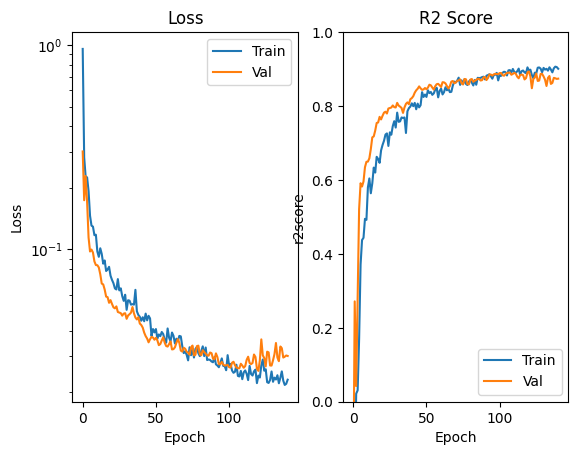

In [126]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2_score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2_score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

plot_history(history)